# **Learning from pre-built models Assignment**

**Import required libraries**

In [1]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os

In [2]:
! pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pradnyeshsawant","key":"c4be9efa03dde0f1f268aa969ba84e74"}'}

In [4]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle competitions download -c dogs-vs-cats --force

100% 812M/812M [00:41<00:00, 22.2MB/s]
100% 812M/812M [00:41<00:00, 20.5MB/s]


In [5]:
! unzip -q dogs-vs-cats.zip
! unzip -q train.zip

## **Prepare Training Data**

In [6]:
filenames = os.listdir('train')

In [7]:
categories = []

for filename in filenames:
  category = filename.split('.')[0]
  if category == 'dog':
    categories.append(1)
  else:
    categories.append(0)

In [8]:
df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})
df.head()

,filename,category
0,dog.6662.jpg,1
1,cat.4288.jpg,0
2,dog.658.jpg,1
3,cat.1968.jpg,0
4,cat.1029.jpg,0


In [9]:
df['category'] = df['category'].astype('string')

<Axes: xlabel='category'>

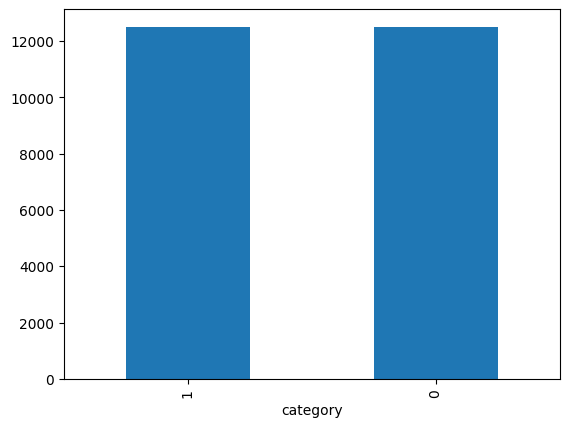

In [10]:
df.category.value_counts().plot.bar()

**Check Sample Image**

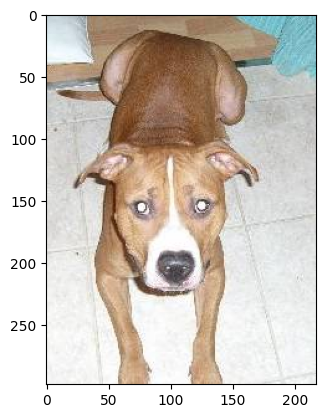

In [11]:
sample = random.choice(filenames)
image = load_img('train/'+sample)
plt.imshow(image)

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, GlobalMaxPooling2D
from keras import applications
from keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Model

image_size = 150
input_shape = (image_size, image_size, 3)

epochs = 5
batch_size = 16

pre_trained_model = VGG16(input_shape=input_shape, include_top=False, weights='imagenet')

for layer in pre_trained_model.layers[:15]:
  layer.trainable = False

for later in pre_trained_model.layers[15:]:
  layer.trainable = True

last_layer = pre_trained_model.get_layer('block5_pool')
last_output = last_layer.output

x = GlobalMaxPooling2D()(last_output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(pre_trained_model.input, x)

model.compile(loss='binary_crossentropy', optimizer=optimizers.SGD(learning_rate=0.0001, momentum=0.9), metrics=['accuracy'])

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 150, 150, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 150, 150, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 75, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 75, 75, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 37, 37, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 37, 37, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 18, 18, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 18, 18, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 18, 18, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 9, 9, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 9, 9, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling2d                 │ (None, 512)                 │               0 │
│ (GlobalMaxPooling2D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         262,6

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 7,342,593 (28.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

## **Prepare Train and Test Data**

In [13]:
train_df, validate_df = train_test_split(df, test_size=0.1)

In [14]:
train_df = train_df.reset_index()
validate_df = validate_df.reset_index()

In [15]:
train_df

,index,filename,category
0,9332,cat.4231.jpg,0
1,23987,cat.10613.jpg,0
2,21159,dog.5014.jpg,1
3,23304,dog.3397.jpg,1
4,1111,dog.10869.jpg,1
...,...,...,...
22495,14923,cat.4305.jpg,0
22496,12812,cat.466.jpg,0
22497,15996,dog.7327.jpg,1
22498,9994,dog.1707.jpg,1


In [16]:
total_train = train_df.shape[0]
total_validate = validate_df.shape[0]

In [17]:
total_train, total_validate

(22500, 2500)

**Training Data Generator**

In [18]:
train_datagen = ImageDataGenerator(rotation_range=15, rescale=1/255.,shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest', width_shift_range=0.1, height_shift_range=0.1)

train_generator = train_datagen.flow_from_dataframe(
    train_df, "train/",
    x_col='filename',
    y_col='category',
    class_mode='binary',
    target_size=(image_size, image_size),
    batch_size=batch_size
)

Found 22500 validated image filenames belonging to 2 classes.


**Validation Generator**

In [19]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_dataframe(
    validate_df,
    "train/",
    x_col='filename',
    y_col='category',
    class_mode='binary',
    target_size=(image_size, image_size),
    batch_size=batch_size
)

Found 2500 validated image filenames belonging to 2 classes.


**See sample generated images**

Found 1 validated image filenames.


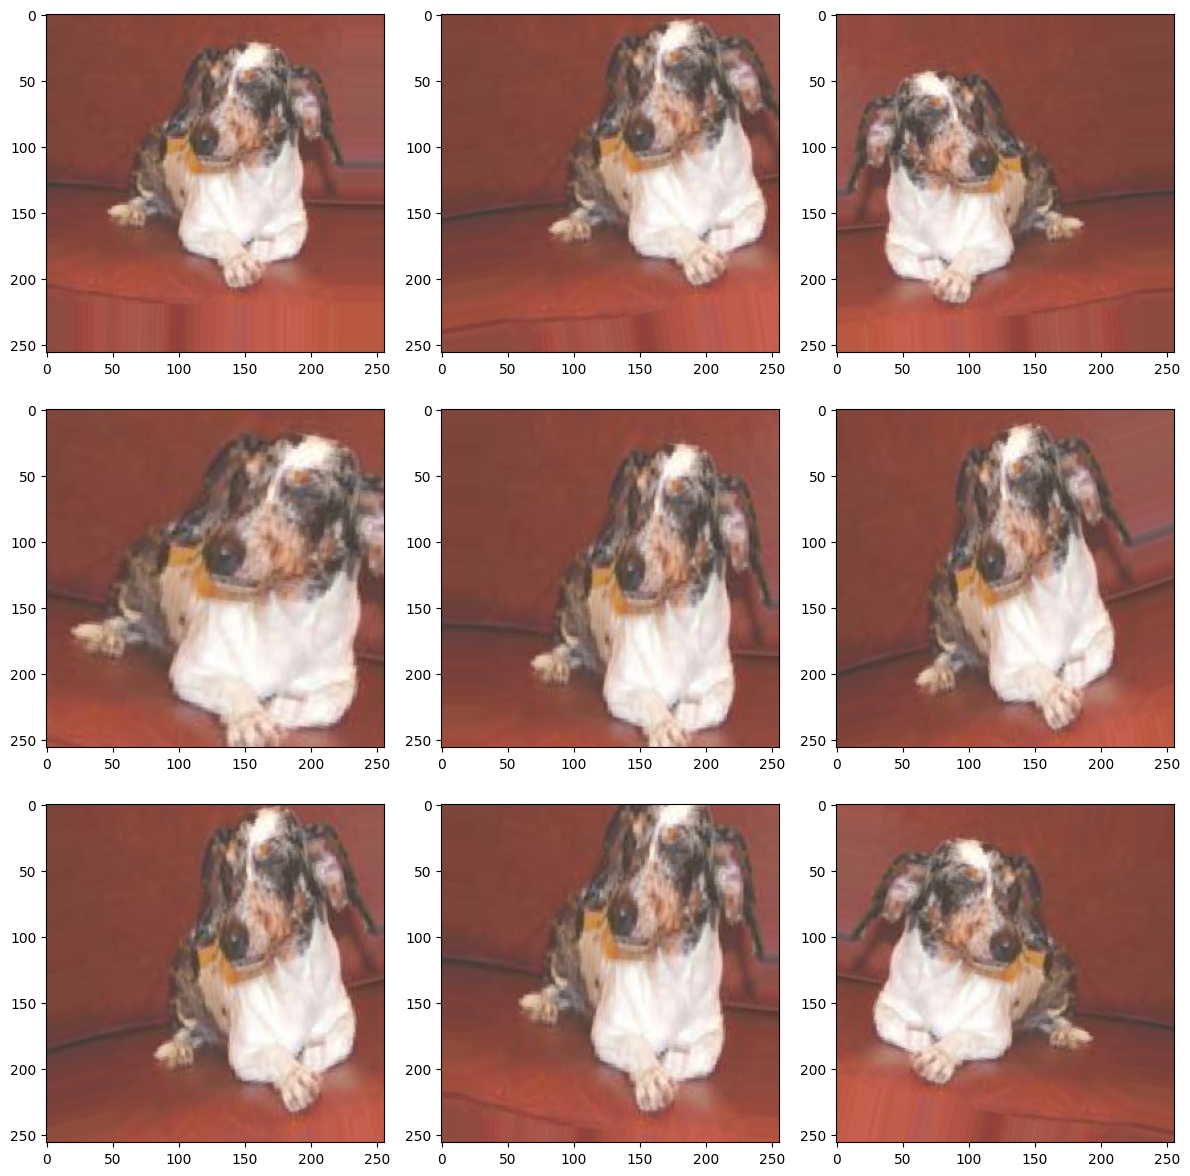

In [20]:
example_df = train_df.sample(n=1).reset_index(drop=True)

example_generator = train_datagen.flow_from_dataframe(example_df, "train/", x_col='filename', y_col='category', class_mode=None)

plt.figure(figsize=(12, 12))
for i in range(0, 9):
    plt.subplot(3, 3, i+1)
    for X_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
plt.tight_layout()
plt.show()

## **Fit Model**

In [21]:
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator, validation_steps=total_validate//batch_size, steps_per_epoch=total_train//batch_size, verbose=1)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1406/1406 ━━━━━━━━━━━━━━━━━━━━ 205s 139ms/step - accuracy: 0.7493 - loss: 0.4764 - val_accuracy: 0.9255 - val_loss: 0.1848
Epoch 2/5
   1/1406 ━━━━━━━━━━━━━━━━━━━━ 1:04 46ms/step - accuracy: 1.0000 - loss: 0.0753

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1406/1406 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step - accuracy: 1.0000 - loss: 0.0753 - val_accuracy: 0.5000 - val_loss: 0.7092
Epoch 3/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 190s 134ms/step - accuracy: 0.9072 - loss: 0.2214 - val_accuracy: 0.9227 - val_loss: 0.1725
Epoch 4/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 23us/step - accuracy: 0.9375 - loss: 0.2733 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 5/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 190s 135ms/step - accuracy: 0.9241 - loss: 0.1853 - val_accuracy: 0.9431 - val_loss: 0.1484


In [25]:
loss, accuracy = model.evaluate(validation_generator, steps=total_validate//batch_size, verbose=0)
print("Test: accuracy = %f  ;  loss = %f " % (accuracy, loss))

Test: accuracy = 0.943109  ;  loss = 0.148359 


In [35]:
Y_val = validate_df['category'].astype('int')
y_pred =  model.predict(validation_generator)

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step


In [36]:
threshold = 0.5
y_final = np.where(y_pred > threshold, 1,0)

In [37]:
y_final.size

2500

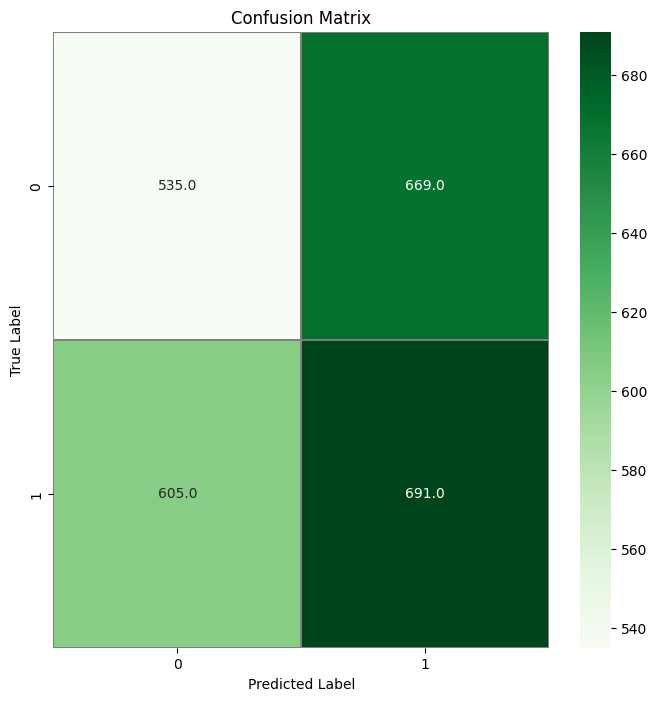

In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Predict the values from the validation dataset

# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_val, y_final)
# plot the confusion matrix
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="Greens",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(Y_val, y_final, target_names=['0','1'])

print(report)

              precision    recall  f1-score   support

           0       0.47      0.44      0.46      1204
           1       0.51      0.53      0.52      1296

    accuracy                           0.49      2500
   macro avg       0.49      0.49      0.49      2500
weighted avg       0.49      0.49      0.49      2500



## Prepare Testing Data

In [71]:
import shutil
#os.mkdir('test')

test_data = np.random.choice(os.listdir('train'), 12500, replace=False)

for imageName in test_data:
  shutil.move(os.path.join('train', imageName), 'test')

In [72]:
test_filenames = os.listdir("test")
test_df = pd.DataFrame({
    'filename': test_filenames
})
nb_samples = test_df.shape[0]

In [74]:
test_df.head()

,filename
0,dog.6662.jpg
1,cat.4288.jpg
2,cat.1968.jpg
3,cat.1029.jpg
4,dog.3432.jpg


## Create Testing Generator

In [75]:
test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_dataframe(
    test_df,
    "test/",
    x_col='filename',
    y_col=None,
    class_mode=None,
    batch_size=batch_size,
    target_size=(image_size, image_size),
    shuffle=False
)

Found 12690 validated image filenames.


In [77]:
predict = model.predict(test_generator, steps=int(np.ceil(nb_samples/batch_size)))
threshold = 0.5
test_df['category'] = np.where(predict > threshold, 1,0)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


794/794 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step


## See Predicted Result

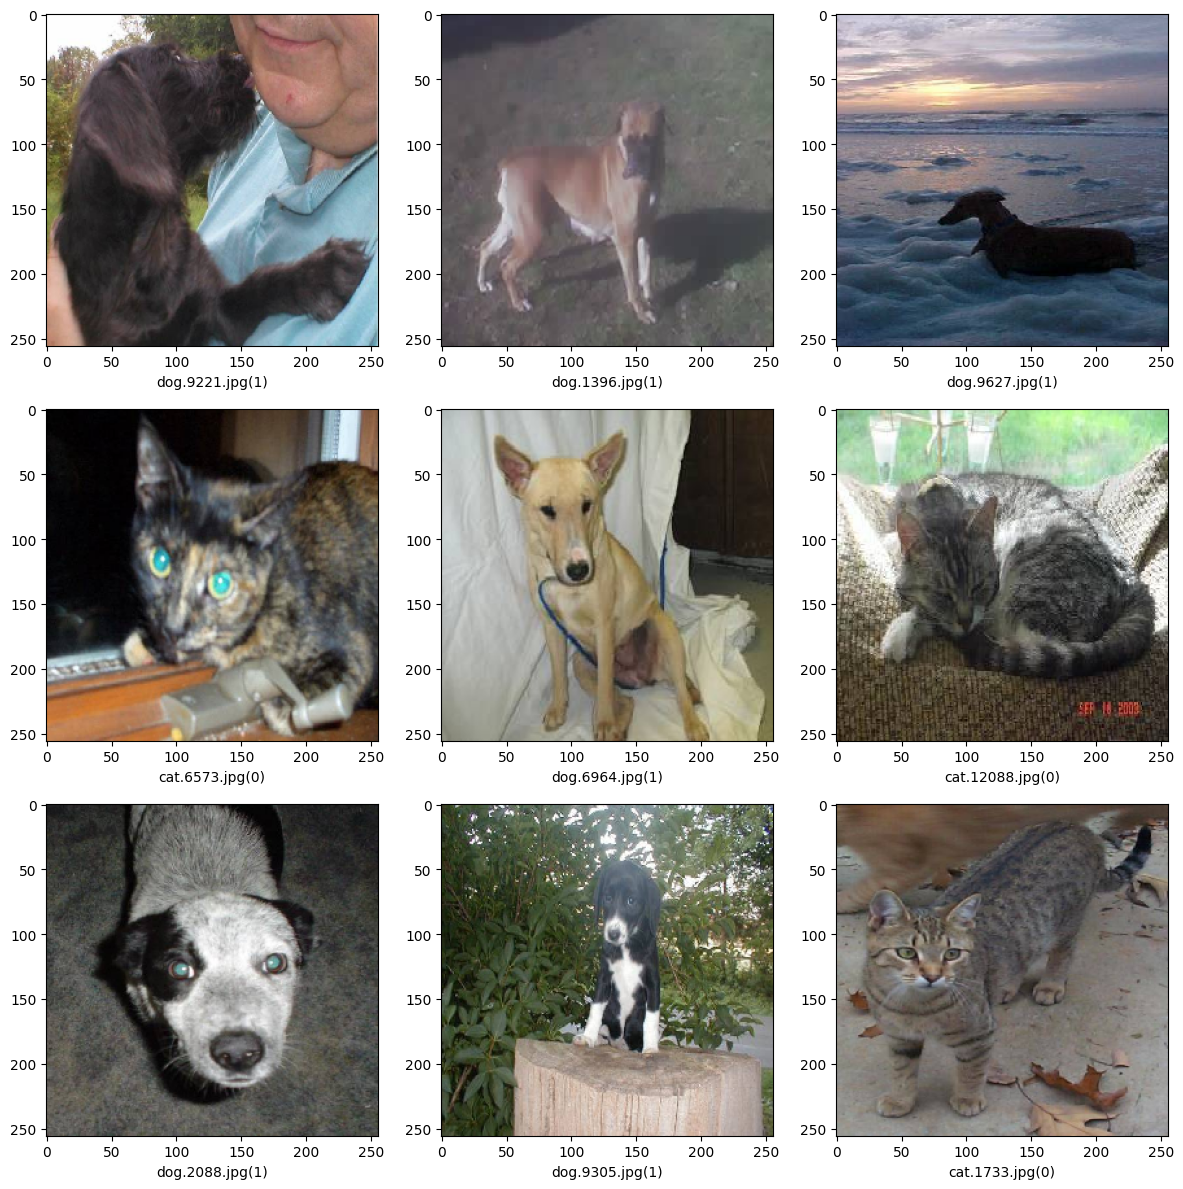

In [78]:
sample_test = test_df.sample(n=9).reset_index()
sample_test.head()
plt.figure(figsize=(12, 12))
for index, row in sample_test.iterrows():
    filename = row['filename']
    category = row['category']
    img = load_img("test/"+filename, target_size=(256, 256))
    plt.subplot(3, 3, index+1)
    plt.imshow(img)
    plt.xlabel(filename + '(' + "{}".format(category) + ')')
plt.tight_layout()
plt.show()

## **Submission**

In [85]:
import seaborn as sns

submission_df = test_df.copy()
submission_df['id'] = submission_df['filename'].str.split('.').str[0]
submission_df['label'] = submission_df['category']
submission_df.drop(['filename', 'category'], axis=1, inplace=True)
submission_df.to_csv('submission_16092024.csv', index=False)

<Axes: xlabel='label'>

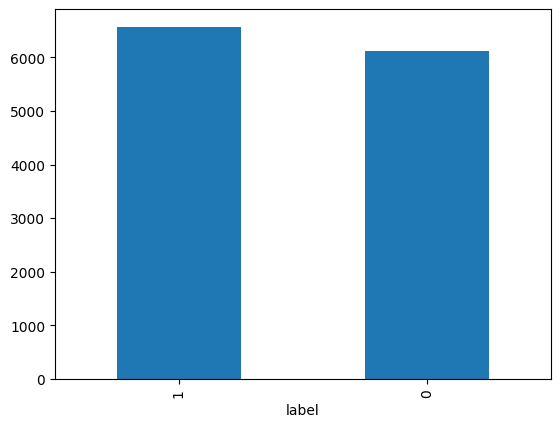

In [86]:
submission_df['label'].value_counts().plot.bar()